
<div dir=ltr align=center>

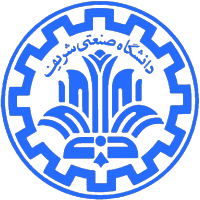

<font color=0F5298 size=7>
Machine Learning <br>
<font color=2565AE size=5>
Computer Engineering Department <br>
Fall 2025 <br>
<font color=3C99D size=5>
    Clustering: K-Means Clustering<br>
<font color=696880 size=4>
    Prepared by Benyamin Ghanbari <br>

<font color=696880 size=2>
    Curated by Alireza Mirshafieian

____

# Student Information

In [1]:
student_number = '402102562'
full_name = 'Amitis Mirabedini'

### Image Segmentation Using K-Means Clustering for Color-Based Region Extraction

### Description: 

In this project, you will implement **K-Means clustering from scratch** and use it to perform image segmentation based on color similarity. **Image segmentation** is the process of dividing an image into meaningful regions. In this assignment, segmentation is done using **color clustering**, where every pixel is grouped into one of K color clusters.

**⚠️ Notice:** You are allowed to use **only the imported libraries** and must **follow the provided function structure**.



# 📝 **Project Instructions**

1. **Load the image**  
   Load the input image and convert it into an **RGB numerical array**.

2. **Reshape image to pixels**  
   Flatten the image into a **2D array**, where each row represents one pixel (**R, G, B**).

3. **Initialize K cluster centers**  
   Randomly select **K pixels** to serve as the starting cluster centers.

4. **Assign pixels to nearest cluster**  
   Compute **distances** and assign each pixel to the **closest cluster center**.

5. **Update cluster centers**  
   Recalculate each center as the **mean color** of all pixels assigned to that cluster.

6. **K-Means algorithm**  
   Repeat **assignment** and **update steps** until **convergence** or **max iterations**.

7. **Reconstruct segmented image**  
   Replace each pixel with the **color of its assigned cluster center**.

8. **Using the Elbow Method**  
   Compute the Compute Within-Cluster Sum of Squares **WCSS** for various **K values** to help estimate an **optimal K**.

9. **Run the segmentation**  
   Apply your **full K-Means pipeline** to segment the chosen image.

10. **Display results**  
    Plot and **visualize** the original and segmented images **side-by-side**.


# 📤 **Expected Output**

- A **segmented image** produced by your **K-Means implementation**  
- A **plot showing the Elbow Method curve** (**WCSS vs. K**)  
- **Observe** how changing **K** affects segmentation


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [13]:

# Step 1: Load the image

def load_image(path):

    img = Image.open(r"C:\Users\Notebook\Downloads\matryoshka.jpg")
    img = img.convert('RGB')
    data = np.array(img)
    
    return data


# Step 2: Reshape image to pixels

def preprocess_image(image_data):

    height, width, channels = image_data.shape 
    pixels = image_data.reshape(-1, channels)
    return pixels



In [14]:

# Step 3: Initialize K cluster centers

def initialize_centers(pixels, k):
    n_pixels = pixels.shape[0]
    random_indices = np.random.choice(n_pixels, size = k, replace = False)
    centers = pixels[random_indices]
    
    return centers


# Step 4: Assign pixels to nearest cluster

def assign_clusters(pixels, centers):
    distances = np.zeros((pixels.shape[0], centers.shape[0]))

    for i, center in enumerate(centers):
        distances[:,i] = np.sqrt(np.sum((pixels - center) ** 2, axis = 1))
   
    labels = np.argmin(distances, axis = 1) 
    return labels


# Step 5: Update cluster centers
    
def update_centers(pixels, labels, k):

    new_centers = np.zeros((k, 3))
    
    for i in range(k):
        cluster_pixels = pixels[labels == i]
        
        if len(cluster_pixels) > 0:
            new_centers[i] = np.mean(cluster_pixels, axis=0)
        else:
            random_idx = np.random.choice(pixels.shape[0], 1)
            new_centers[i] = pixels[random_idx]
    
    return np.array(new_centers)



# Step 6: K-Means algorithm

def kmeans(pixels, k, max_iters=10, tol=1e-4):
    centers = initialize_centers(pixels, k)
    
    for iteration in range(max_iters):
        labels = assign_clusters(pixels, centers)
        
        old_centers = centers.copy()
        centers = update_centers(pixels, labels, k)
        
        center_shift = np.sqrt(np.sum((centers - old_centers) ** 2, axis=1))
        max_shift = np.max(center_shift)
        
        if max_shift < tol:
            break
    
    return centers, labels

In [15]:

# Step 7: Reconstruct segmented image

def recreate_image(labels, centers, image_shape):
    
    segmented_flat = np.zeros((labels.shape[0], 3))
    
    for i in range(len(centers)):
        mask = (labels == i)
        segmented_flat[mask] = centers[i]
    
    segmented = segmented_flat.reshape(image_shape)
    
    segmented = segmented.astype(np.uint8)
    
    return segmented

In [16]:
def calculate_wcss(pixels, max_k=10):
    
    wcss = []
    
    for k in range(1, max_k + 1):
        print(f"Calculating WCSS for k = {k}...")
        
        centers, labels = kmeans(pixels, k, max_iters=20)  # Fewer iterations for speed
        
        wcss_k = 0
        
        for i in range(k):
            cluster_pixels = pixels[labels == i]
            
            if len(cluster_pixels) > 0:
                distances = np.sum((cluster_pixels - centers[i]) ** 2, axis=1)
                wcss_k += np.sum(distances)
        
        wcss.append(wcss_k)
        
        print(f"  k = {k}, WCSS = {wcss_k:.2f}")
    
    return wcss

def plot_elbow(wcss):
   
    k_values = list(range(1, len(wcss) + 1))
    
    plt.figure(figsize=(10, 6))
    
    plt.plot(k_values, wcss, 'bo-', linewidth=2, markersize=8)
    
    plt.xlabel('Number of Clusters (K)', fontsize=12)
    plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
    plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
    
    plt.grid(True, alpha=0.3)
    
    for k, w in zip(k_values, wcss):
        plt.text(k, w, f'{w:.0f}', ha='center', va='bottom', fontsize=9)
    
    if len(wcss) >= 3:
       
        second_derivative = np.diff(np.diff(wcss))
        if len(second_derivative) > 0:
            elbow_k = np.argmax(np.abs(second_derivative)) + 2  # +2 because of double diff
            plt.axvline(x=elbow_k, color='red', linestyle='--', alpha=0.5, 
                       label=f'Elbow at K={elbow_k}')
            plt.legend()
    
    plt.xticks(k_values)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Step 9: Run the segmentation
def run_segmentation(image_path, k=6):
    
    print(f"Running K-means segmentation with K={k}...")
    
    image_data = load_image(image_path)
    print(f"✓ Image loaded: {image_data.shape}")
    
    pixels = preprocess_image(image_data)
    print(f"✓ Pixels array: {pixels.shape}")
    
    print("Running K-means algorithm...")
    centers, labels = kmeans(pixels, k, max_iters=100, tol=1e-4)
    
    segmented_image = recreate_image(labels, centers, image_data.shape)
    print(f"✓ Segmentation complete")
    
    return segmented_image, centers, labels, image_data


Starting K-means Image Segmentation Pipeline
Image: matryoshka.jpg

FINAL RESULTS

Loading and processing image...

1. Calculating WCSS for K=1 to 10 (Elbow Method)...
Calculating WCSS for k = 1...
  k = 1, WCSS = 3235399381.58
Calculating WCSS for k = 2...
  k = 2, WCSS = 1054740226.64
Calculating WCSS for k = 3...
  k = 3, WCSS = 710042147.35
Calculating WCSS for k = 4...
  k = 4, WCSS = 500170069.64
Calculating WCSS for k = 5...
  k = 5, WCSS = 416001870.05
Calculating WCSS for k = 6...
  k = 6, WCSS = 328563079.26
Calculating WCSS for k = 7...
  k = 7, WCSS = 283379237.08
Calculating WCSS for k = 8...
  k = 8, WCSS = 254903099.40
Calculating WCSS for k = 9...
  k = 9, WCSS = 241201647.51
Calculating WCSS for k = 10...
  k = 10, WCSS = 201431977.12

2. Running K-means segmentation with K=6...


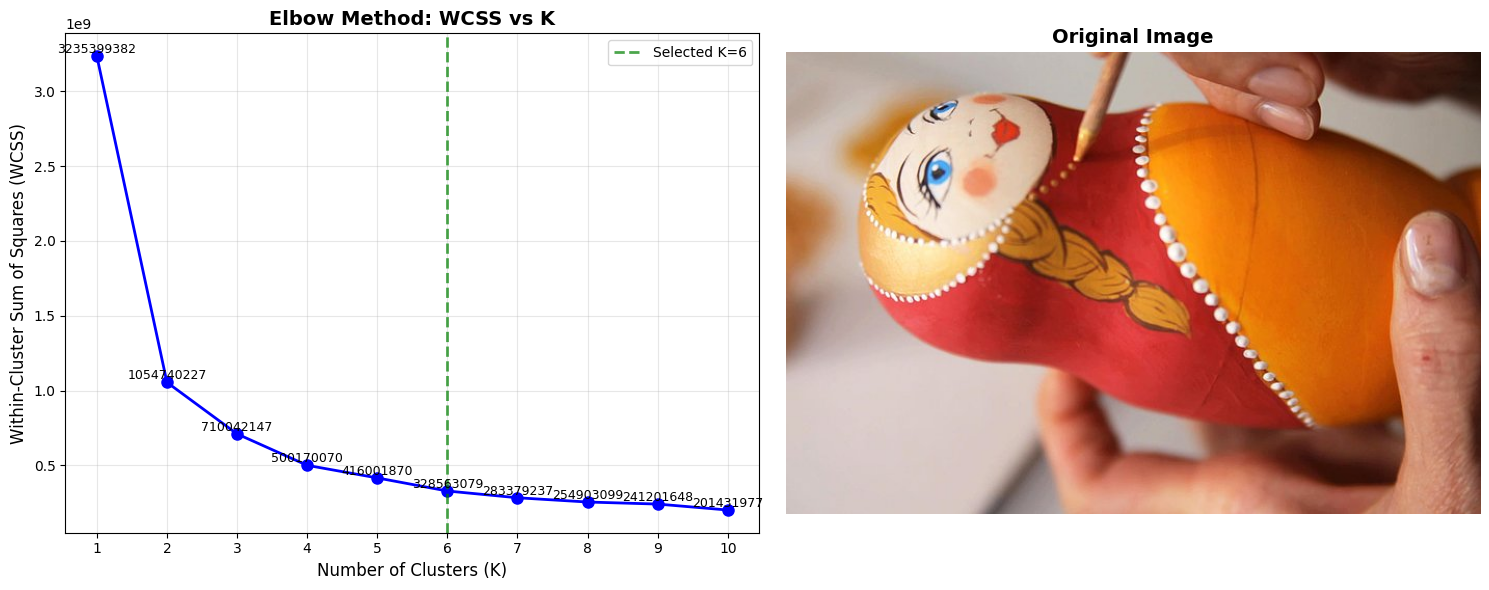

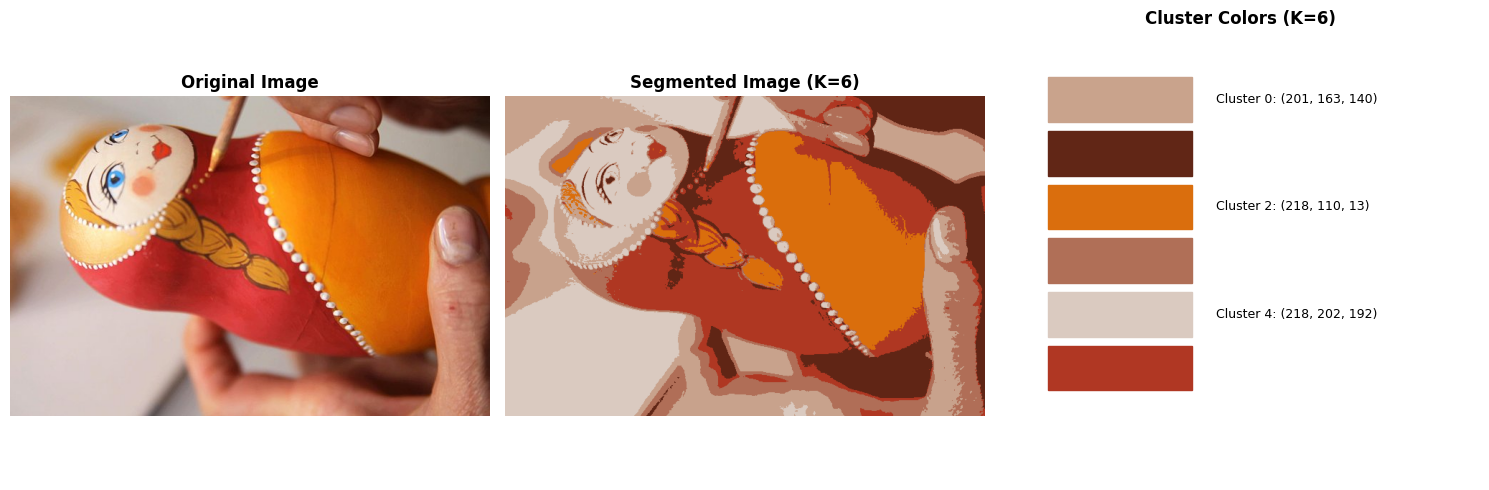


------------------------------------------------------------
SUMMARY
------------------------------------------------------------
Image dimensions: (446, 669, 3)
Total pixels: 298,374

WCSS values:
  K=1: WCSS = 3,235,399,382
  K=2: WCSS = 1,054,740,227
  K=3: WCSS = 710,042,147
  K=4: WCSS = 500,170,070
  K=5: WCSS = 416,001,870
  K=6: WCSS = 328,563,079
  K=7: WCSS = 283,379,237
  K=8: WCSS = 254,903,099
  K=9: WCSS = 241,201,648
  K=10: WCSS = 201,431,977

Segmentation with K=6:
  Cluster 0:  58,414 pixels ( 19.6%)
  Cluster 1:  36,084 pixels ( 12.1%)
  Cluster 2:  43,789 pixels ( 14.7%)
  Cluster 3:  38,418 pixels ( 12.9%)
  Cluster 4:  67,691 pixels ( 22.7%)
  Cluster 5:  53,978 pixels ( 18.1%)

PROCESS COMPLETE!
✓ Segmented image saved as 'segmented_k6_result.jpg'


In [20]:
def display_final_results(image_path):
    print("\n" + "=" * 60)
    print("FINAL RESULTS")
    print("=" * 60)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    print("\nLoading and processing image...")
    image_data = load_image(image_path)
    pixels = preprocess_image(image_data)
    
    print("\n1. Calculating WCSS for K=1 to 10 (Elbow Method)...")
    wcss = calculate_wcss(pixels, max_k=10)
    
    k_values = list(range(1, len(wcss) + 1))
    axes[0].plot(k_values, wcss, 'bo-', linewidth=2, markersize=8)
    axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
    axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
    axes[0].set_title('Elbow Method: WCSS vs K', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks(k_values)
    
    for k, w in zip(k_values, wcss):
        axes[0].text(k, w, f'{w:.0f}', ha='center', va='bottom', fontsize=9)
    
    axes[0].axvline(x=6, color='green', linestyle='--', alpha=0.7, 
                   label=f'Selected K=6', linewidth=2)
    axes[0].legend()
    
    print("\n2. Running K-means segmentation with K=6...")
    centers, labels = kmeans(pixels, k=6, max_iters=100, tol=1e-4)
    segmented_image = recreate_image(labels, centers, image_data.shape)
    
    axes[1].imshow(image_data)
    axes[1].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
    
    axes2[0].imshow(image_data)
    axes2[0].set_title('Original Image', fontsize=12, fontweight='bold')
    axes2[0].axis('off')
    
    axes2[1].imshow(segmented_image)
    axes2[1].set_title(f'Segmented Image (K=6)', fontsize=12, fontweight='bold')
    axes2[1].axis('off')
    
    axes2[2].axis('off')
    for i, center in enumerate(centers):
        color = center / 255.0
        y_start = 0.8 - (i * 0.12)
        rect = plt.Rectangle((0.1, y_start), 0.3, 0.10, color=color, 
                            transform=axes2[2].transAxes)
        axes2[2].add_patch(rect)
        
        brightness = 0.299*center[0] + 0.587*center[1] + 0.114*center[2]
        text_color = 'white' if brightness < 128 else 'black'
        axes2[2].text(0.45, y_start + 0.05, 
                     f'Cluster {i}: ({center[0]:.0f}, {center[1]:.0f}, {center[2]:.0f})',
                     transform=axes2[2].transAxes,
                     color=text_color, fontsize=9, verticalalignment='center')
    
    axes2[2].set_xlim(0, 1)
    axes2[2].set_ylim(0, 1)
    axes2[2].set_title('Cluster Colors (K=6)', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "-" * 60)
    print("SUMMARY")
    print("-" * 60)
    print(f"Image dimensions: {image_data.shape}")
    print(f"Total pixels: {pixels.shape[0]:,}")
    print(f"\nWCSS values:")
    for k, w in zip(k_values, wcss):
        print(f"  K={k}: WCSS = {w:,.0f}")
    
    print(f"\nSegmentation with K=6:")
    total_pixels = len(labels)
    for i in range(6):
        count = np.sum(labels == i)
        percentage = (count / total_pixels) * 100
        print(f"  Cluster {i}: {count:7,d} pixels ({percentage:5.1f}%)")
    
    print("\n" + "=" * 60)
    print("PROCESS COMPLETE!")
    print("=" * 60)
    
    return segmented_image, centers, labels


def main():
    image_path = "matryoshka.jpg"
    
    try:
        print("Starting K-means Image Segmentation Pipeline")
        print(f"Image: {image_path}")
        
        segmented_img, centers, labels = display_final_results(image_path)
        
        save_choice = input("\nDo you want to save the segmented image? (y/n): ")
        if save_choice.lower() == 'y':
            filename = "segmented_k6_result.jpg"
            Image.fromarray(segmented_img).save(filename)
            print(f"✓ Segmented image saved as '{filename}'")
            
    except FileNotFoundError:
        print(f"Error: Image not found at '{image_path}'")
    except Exception as e:
        print(f"Error: {str(e)}")


if __name__ == "__main__":
    main()